# Day 3 — Text Preprocessing + Baseline Model

Cleaning text, extracting TF-IDF features, training Logistic Regression and Naive Bayes.

In [1]:
import pandas as pd
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

df = pd.read_csv("train.tsv", delimiter='\t', header=None, names=['text', 'label'])
print("Loaded:", df.shape)
print(df.head(3))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/keerthigirish/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/keerthigirish/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/keerthigirish/nltk_data...


Loaded: (6920, 2)
                                                text  label
0  a stirring , funny and finally transporting re...      1
1  apparently reassembled from the cutting room f...      0
2  they presume their audience wo n't sit still f...      0


In [2]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add custom noise words we spotted in EDA
stop_words.update(['lrb', 'rrb', 'film', 'movie', 'one', 'make'])

def clean_text(text):
    # lowercase
    text = text.lower()
    # remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # tokenise
    words = text.split()
    # remove stopwords and lemmatise
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

# Apply to whole dataset
df['clean_text'] = df['text'].apply(clean_text)

print("Before:", df['text'][0])
print("\nAfter:", df['clean_text'][0])

Before: a stirring , funny and finally transporting re imagining of beauty and the beast and 1930s horror films

After: stirring funny finally transporting imagining beauty beast horror film


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# TF-IDF vectorisation
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training samples: 5536
Test samples: 1384
Features: 5000


In [4]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

# Train Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_preds)

print(f"Logistic Regression accuracy: {lr_acc:.4f}")
print(f"Naive Bayes accuracy:         {nb_acc:.4f}")
print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))


Logistic Regression accuracy: 0.7919
Naive Bayes accuracy:         0.7977

--- Logistic Regression Report ---
              precision    recall  f1-score   support

    Negative       0.83      0.72      0.77       671
    Positive       0.76      0.86      0.81       713

    accuracy                           0.79      1384
   macro avg       0.80      0.79      0.79      1384
weighted avg       0.80      0.79      0.79      1384



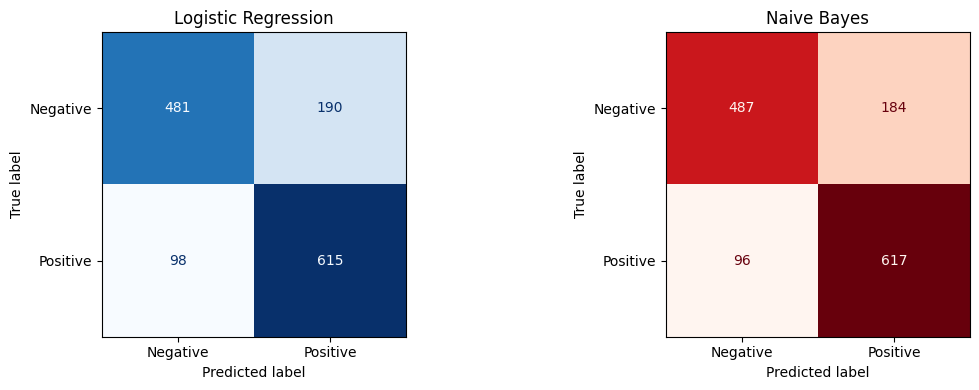

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, 
    display_labels=['Negative', 'Positive'], 
    colorbar=False, ax=ax1, cmap='Blues')
ax1.set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, nb_preds, 
    display_labels=['Negative', 'Positive'], 
    colorbar=False, ax=ax2, cmap='Reds')
ax2.set_title('Naive Bayes')

plt.tight_layout()
plt.savefig('chart_confusion_matrix.png', dpi=150)
plt.show()

## Baseline Model Results

| Model | Accuracy | F1 (avg) |
|-------|----------|----------|
| Logistic Regression | 79.2% | 0.79 |
| Naive Bayes | 79.8% | 0.79 |

**Observations:**
- Both models perform similarly — typical for small datasets
- Model leans positive: 190 false positives vs 98 false negatives
- Logistic Regression chosen as baseline (more interpretable)
- **Target:** beat 79.2% with DistilBERT on Day 4